# Módulo 3

In [5]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import matplotlib.pyplot as plt


In [7]:
df = pd.read_excel('meteorite_landings.xlsx', 'in')
df.head(5)

,name,id,nametype,recclass,mass (g),fall,year,reclat,reclong,GeoLocation
0,Aachen,1,Valid,L5,21.0,Fell,1880.0,50.77500,6.08333,"(50.775, 6.08333)"
1,Aarhus,2,Valid,H6,720.0,Fell,1951.0,56.18333,10.23333,"(56.18333, 10.23333)"
2,Abee,6,Valid,EH4,107000.0,Fell,1952.0,54.21667,-113.00000,"(54.21667, -113.0)"
3,Acapulco,10,Valid,Acapulcoite,1914.0,Fell,1976.0,16.88333,-99.90000,"(16.88333, -99.9)"
4,Achiras,370,Valid,L6,780.0,Fell,1902.0,-33.16667,-64.95000,"(-33.16667, -64.95)"


## Gráfico de linhas

##### Relacionando Ano x Quantidade de meteoritos

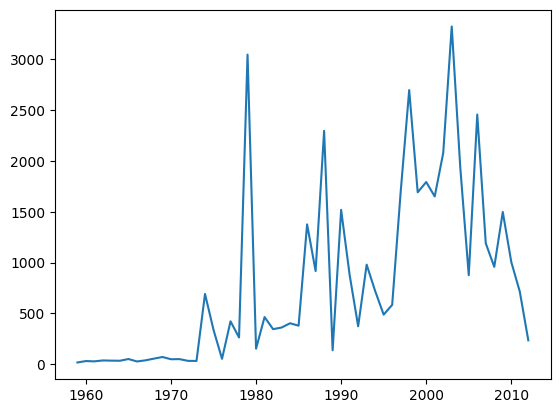

In [8]:
d = df['year'].value_counts()
met = pd.DataFrame({'ano':d.index, 'cont': d.values}).sort_values(by='ano')
met = met[(met['ano'] > 1958) & (met['ano'] < 2013)]
plt.plot(met['ano'], met['cont']) # (eixo x, eixo y)
plt.show()

##### Estilizando o gráfico:

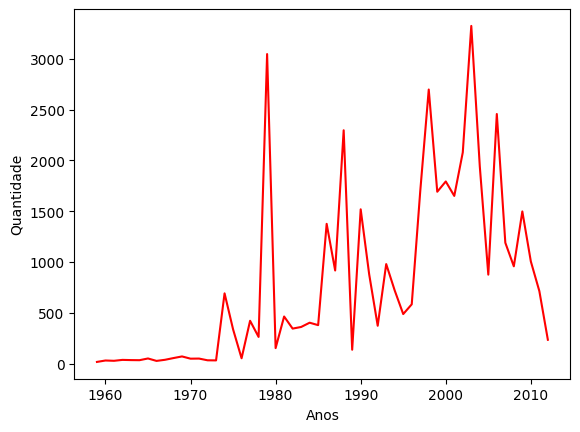

In [9]:
plt.xlabel("Anos")
plt.ylabel("Quantidade")
plt.plot(met['ano'], met['cont'], color="red")
plt.show()

## Gráfico de barras

##### Mostrando Categorias de meteoritos x Média da massa dos meteoritos

In [10]:
barras = df.groupby(by="recclass").agg({"mass (g)":"mean", "id":"count"}).reset_index() #.agg -> adiciona novas colunas
barras = barras[barras["id"] > 300] # filtrando para aparecer somente as classes que tiverem frequência maior que 300 no nosso data frame

<BarContainer object of 13 artists>

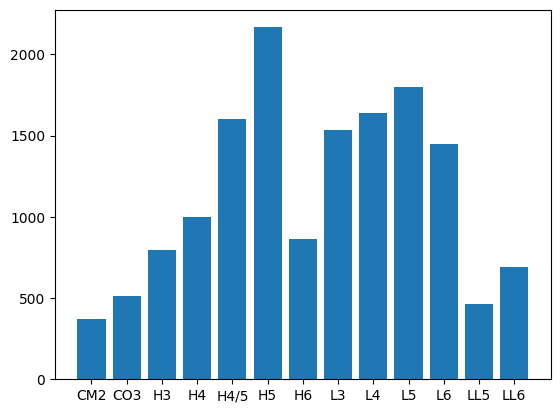

In [11]:
plt.bar(barras["recclass"], barras["mass (g)"])

##### Adicionando informações no gráfico

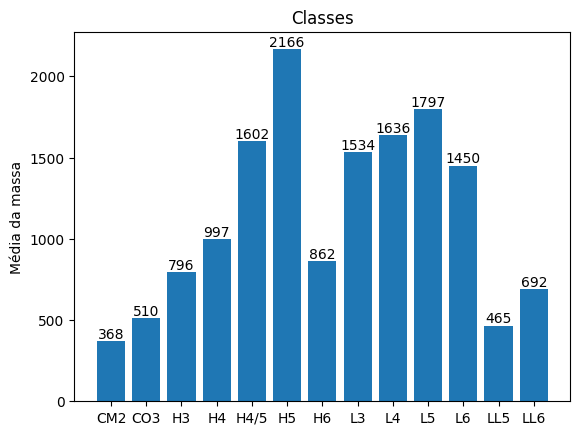

In [12]:
_, ax = plt.subplots()
bar_container = ax.bar(barras["recclass"], barras["mass (g)"])
ax.set(ylabel='Média da massa', title='Classes')
ax.bar_label(bar_container, fmt='{:.0f}')
plt.show()

#### Gráfico de barras horizontal

<BarContainer object of 13 artists>

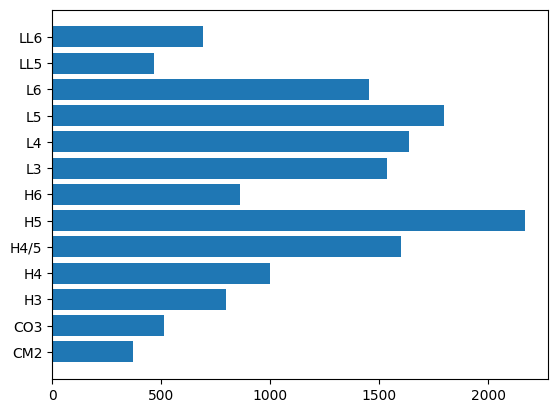

In [13]:
plt.barh(barras['recclass'], barras['mass (g)'])

#### Mudando a cor

<BarContainer object of 13 artists>

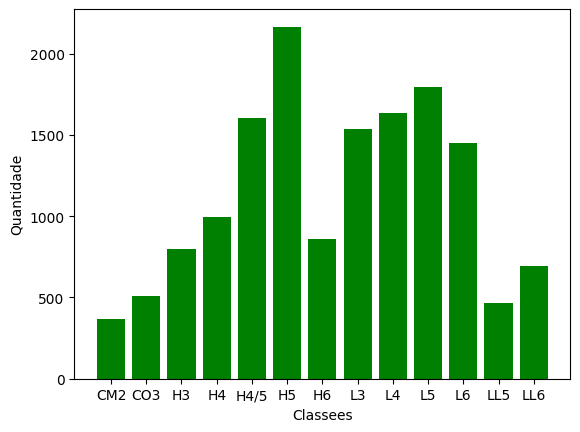

In [14]:
plt.xlabel("Classees")
plt.ylabel("Quantidade")
plt.bar(barras["recclass"], barras["mass (g)"], color="green")

## Gráfico de dispersão

##### Longitude x Latitude

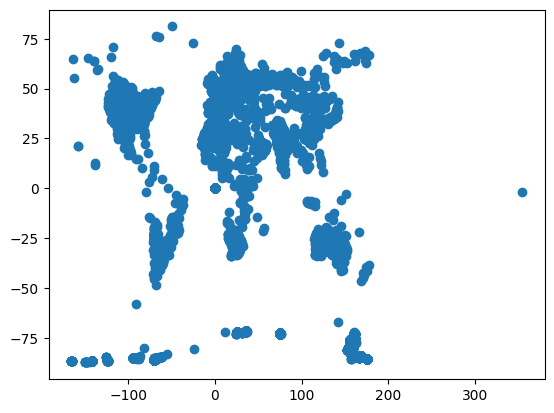

In [15]:
plt.scatter(df['reclong'], df['reclat']) # eixo x, eixo y

##### Removendo possível outlier

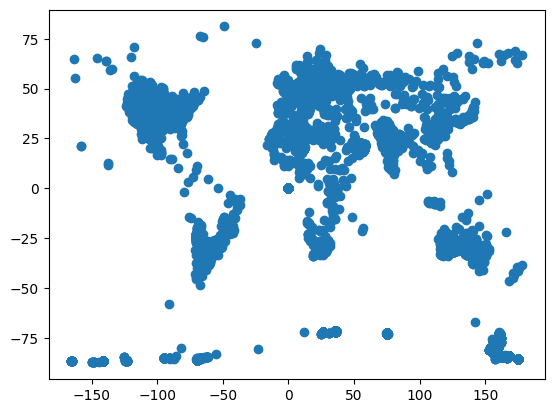

In [16]:
df_new = df[df["reclong"] < 300]
plt.scatter(df_new["reclong"], df_new["reclat"])

##### Estilizando o gráfico

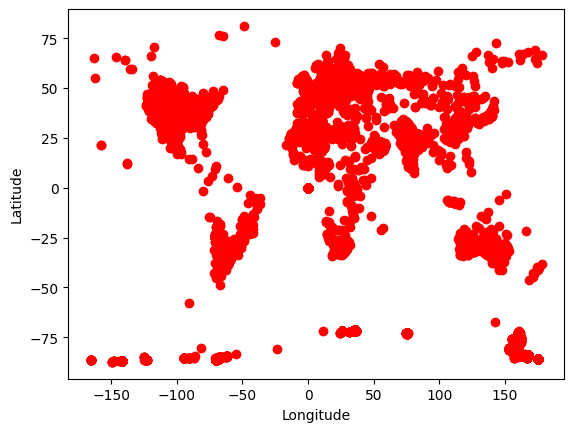

In [17]:
# Alterando a cor e adicionanod labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.scatter(df_new["reclong"], df_new["reclat"], color="red")

##### Salvando o gráfico
##### OBS.: É preciso que o código do gráfico esteja na mesma célula

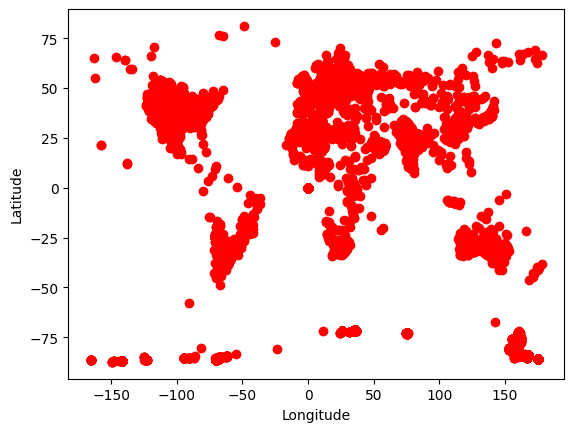

In [18]:
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.scatter(df_new["reclong"], df_new["reclat"], color="red")
plt.savefig("mapa_dos_meteoritos.jpg")

## Aula: Histograma com Matplotlib

## Histograma da latitude

In [19]:
df_new2 = df[df["reclong"] < 300] # removenod outliers

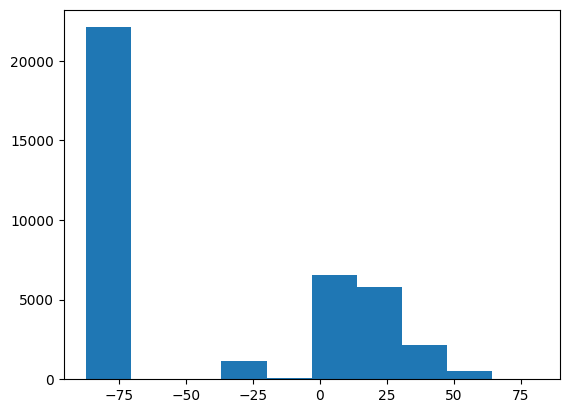

In [20]:
plt.hist(df_new2['reclat'])
plt.show()

##### Variando o número de bins

##### Bins é a quantidade de intervalos usados para agrupar os dados

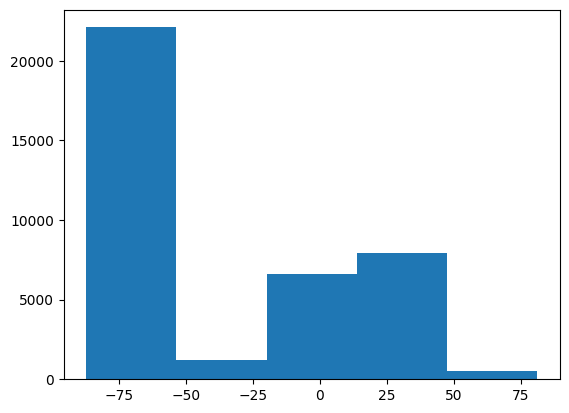

In [21]:
plt.hist(df_new2['reclat'], bins=5)
plt.show()

## Histograma da Longitude

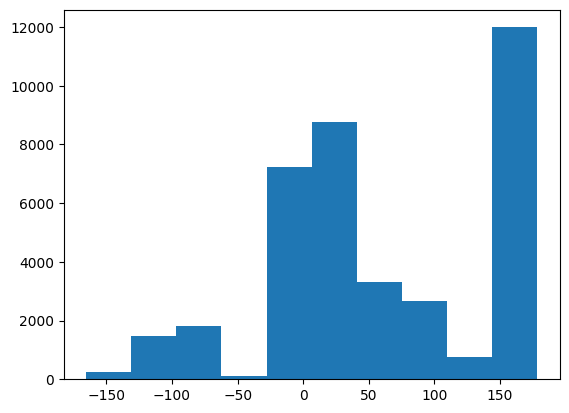

In [22]:
plt.hist(df_new2['reclong'])
plt.show()

##### Alterando a cor

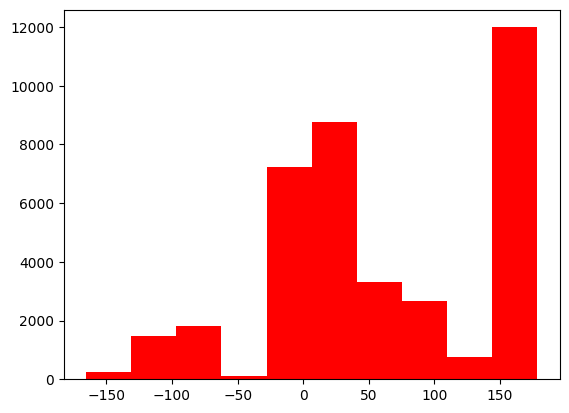

In [23]:
plt.hist(df_new2["reclong"], color="red")
plt.show()

## Histogramas com subplots

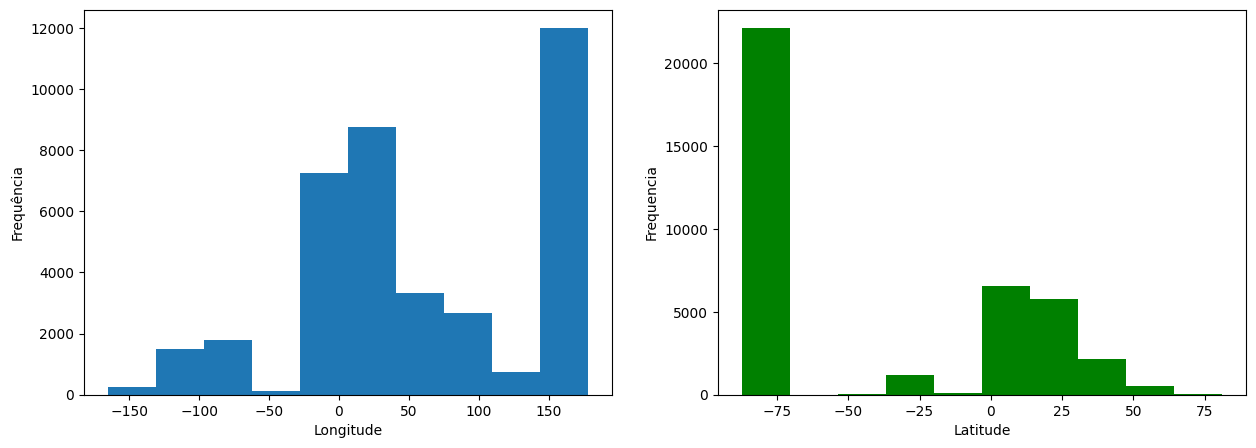

In [24]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1) # linha, coluna, posicao do subplot, ou seja, esse será o primeiro gráfico
plt.hist(df_new2["reclong"])
plt.xlabel("Longitude")
plt.ylabel("Frequência")

plt.subplot(1,2,2) # esse será o segundo gráfico
plt.hist(df_new2["reclat"], color="green")
plt.xlabel("Latitude")
plt.ylabel("Frequencia")
plt.show()


### Latitude e longitude no mesmo gráfico

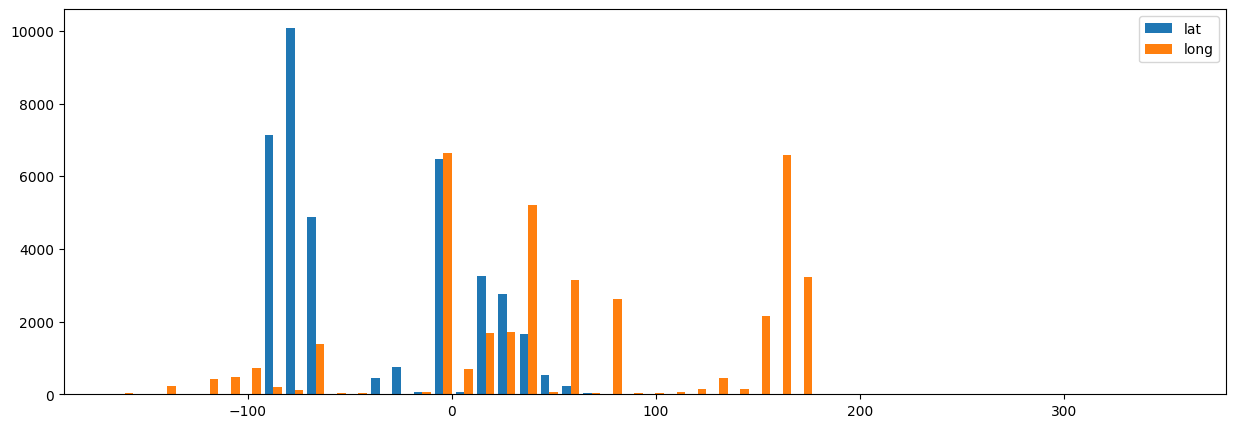

In [25]:
plt.figure(figsize=(15,5))
plt.hist([df['reclat'], df['reclong']], bins=50, label=['lat', 'long'])
plt.legend(loc='upper right')
plt.show()

### Variando o número de bins

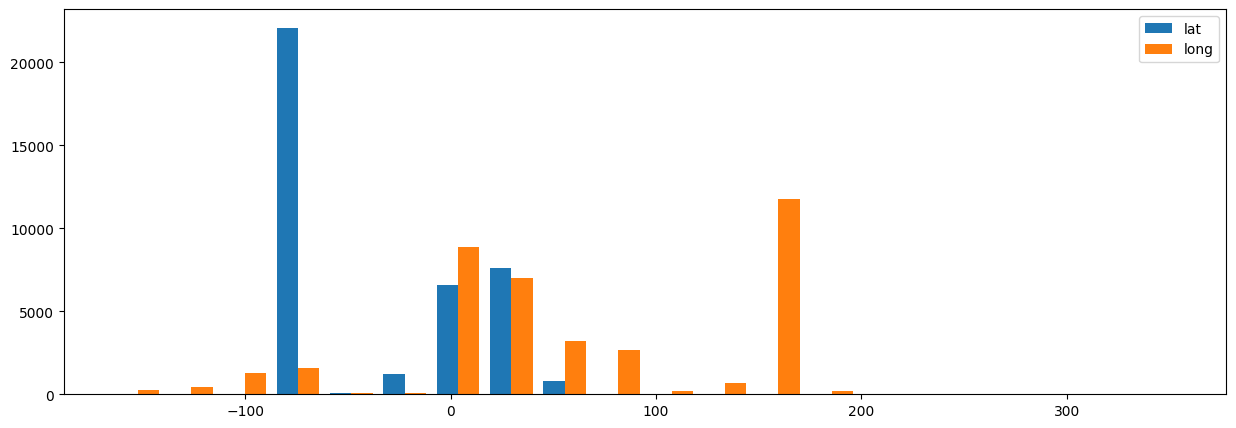

In [26]:
plt.figure(figsize=(15,5))
plt.hist([df['reclat'], df['reclong']], bins=20, label=['lat', 'long'])
plt.legend(loc='upper right')
plt.show()

## Aula: Boxplots com Matplotlib

In [27]:
data_frame = pd.read_excel('sentiment_dataset.xlsx', 'in')
data_frame.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15,30,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5,10,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! ðŸ’ª ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20,40,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8,15,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12,25,Australia,2023,1,15,19


In [28]:
data_frame['Country'].value_counts()

Country
USA               59
USA               55
UK                49
Canada            44
Australia         41
                  ..
Netherlands        1
USA                1
Germany            1
France             1
USA                1
Name: count, Length: 115, dtype: int64

In [29]:
# Mostrando todos os valores de uma coluna
data_frame['Sentiment'].values

array([' Positive  ', ' Negative  ', ' Positive  ', ' Positive  ',
       ' Neutral   ', ' Positive  ', ' Positive  ', ' Positive  ',
       ' Negative  ', ' Neutral   ', ' Positive  ', ' Negative  ',
       ' Positive  ', ' Positive  ', ' Neutral   ', ' Positive  ',
       ' Positive  ', ' Positive  ', ' Neutral   ', ' Negative  ',
       ' Positive  ', ' Positive  ', ' Positive  ', ' Positive  ',
       ' Positive  ', ' Positive  ', ' Positive  ', ' Positive  ',
       ' Positive  ', ' Positive  ', ' Positive  ', ' Positive  ',
       ' Positive  ', ' Positive  ', ' Positive  ', ' Positive  ',
       ' Positive  ', ' Positive  ', ' Positive  ', ' Positive  ',
       ' Positive  ', ' Positive  ', ' Positive  ', ' Positive  ',
       ' Positive  ', ' Positive  ', ' Positive  ', ' Positive  ',
       ' Positive  ', ' Positive  ', ' Positive  ', ' Positive  ',
       ' Anger        ', ' Fear         ', ' Sadness      ',
       ' Disgust      ', ' Happiness    ', ' Joy          ',
       

In [30]:
data_frame['Country'].values

array([' USA      ', ' Canada   ', ' USA        ', ' UK       ',
       ' Australia ', ' India    ', ' Canada   ', ' USA    ',
       ' USA      ', ' Australia ', 'USA', ' Canada   ', ' UK       ',
       ' USA        ', ' India    ', ' USA      ', ' Canada    ',
       ' UK       ', 'USA', ' USA       ', ' India    ', 'USA', ' USA ',
       ' UK       ', ' Canada  ', ' UK ', ' India     ', ' Australia ',
       ' USA      ', ' Canada ', ' UK        ', ' India    ', ' USA ',
       'USA', ' Canada   ', ' UK        ', ' USA ', ' India    ',
       ' Canada ', 'USA', ' USA      ', ' UK ', ' India ', ' Canada   ',
       ' USA      ', ' UK   ', ' India    ', ' Australia ', ' USA       ',
       ' Canada   ', ' UK         ', ' USA     ', ' Canada     ',
       ' USA          ', ' India      ', ' UK         ', ' USA ',
       ' Canada    ', ' Australia  ', ' UK           ', ' Canada       ',
       ' USA       ', 'USA', ' Australia   ', ' India      ',
       ' USA          ', ' Canada     

In [31]:
# Removendo espaços extras das strings

data_frame['Sentiment'] = data_frame['Sentiment'].str.strip() # strip remove espaços em branco que estejam antes ou depois da string
data_frame['Country'] = data_frame['Country'].str.strip()

In [32]:
data_frame_new = data_frame[data_frame['Country'] == 'USA']

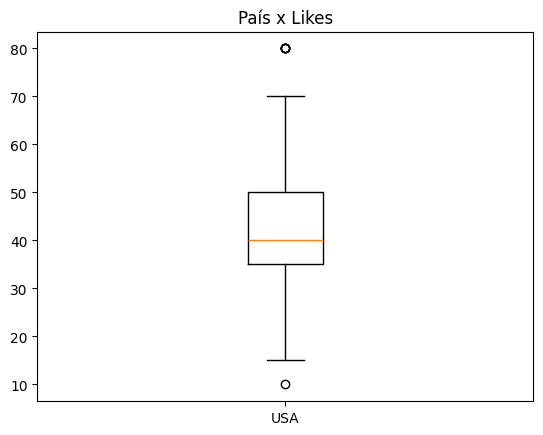

In [33]:
fig, ax = plt.subplots()
ax.boxplot([data_frame_new['Likes']], labels=['USA'])
ax.set_title('País x Likes')
plt.show()

In [34]:
df_new3 = data_frame_new[data_frame_new['Sentiment'] == 'Positive']

In [35]:
data_frame_new['Sentiment'].value_counts()

Sentiment
Positive       18
Joy            17
Excitement     10
Neutral         6
Contentment     5
               ..
Happiness       1
Love            1
Emotion         1
Grateful        1
Jealous         1
Name: count, Length: 79, dtype: int64

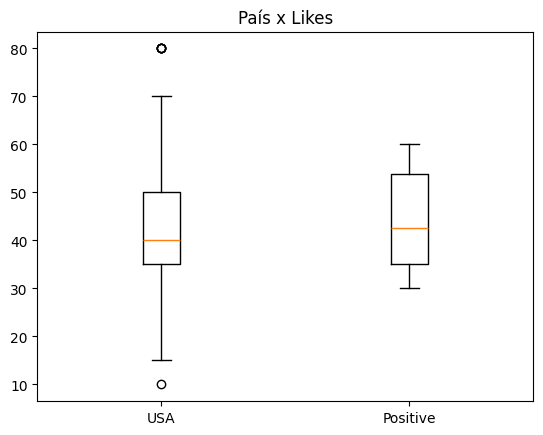

In [36]:
# Colocando dois boxplots lado a lado

fig, ax = plt.subplots()
ax.boxplot([data_frame_new['Likes'], df_new3['Likes']], labels=['USA', 'Positive'])
# df_new3 -> dataframe apenas com valores Positive para Sentiment
ax.set_title("País x Likes")
plt.show()

## Gráficos interativos com Plotly

In [37]:
import plotly.express as px

In [38]:
meteoritos = pd.read_excel("meteorite_landings.xlsx", "in")
sentimentos = pd.read_excel("sentiment_dataset.xlsx", "in")

##### Filtrando linhas do dataset

In [39]:
meteoritos = meteoritos[(meteoritos['year'] > 1958) & (meteoritos['year'] < 2013)]
meteoritos = meteoritos[
    (meteoritos['reclong'] >= -180) & (meteoritos['reclong'] <= 180)
    & (meteoritos['reclat'] >= -90) & (meteoritos['reclat'] <= 90)
]
meteoritos

,name,id,nametype,recclass,mass (g),fall,year,reclat,reclong,GeoLocation
3,Acapulco,10,Valid,Acapulcoite,1914.0,Fell,1976.0,16.88333,-99.90000,"(16.88333, -99.9)"
10,Aioun el Atrouss,423,Valid,Diogenite-pm,1000.0,Fell,1974.0,16.39806,-9.57028,"(16.39806, -9.57028)"
15,Akwanga,432,Valid,H,3000.0,Fell,1959.0,8.91667,8.43333,"(8.91667, 8.43333)"
16,Akyumak,433,Valid,"Iron, IVA",50000.0,Fell,1981.0,39.91667,42.81667,"(39.91667, 42.81667)"
18,Al Zarnkh,447,Valid,LL5,700.0,Fell,2001.0,13.66033,28.96000,"(13.66033, 28.96)"
...,...,...,...,...,...,...,...,...,...,...
45710,Zillah 001,31355,Valid,L6,1475.0,Found,1990.0,29.03700,17.01850,"(29.037, 17.0185)"
45711,Zillah 002,31356,Valid,Eucrite,172.0,Found,1990.0,29.03700,17.01850,"(29.037, 17.0185)"
45712,Zinder,30409,Valid,"Pallasite, ungrouped",46.0,Found,1999.0,13.78333,8.96667,"(13.78333, 8.96667)"
45714,Zubkovsky,31357,Valid,L6,2167.0,Found,2003.0,49.78917,41.50460,"(49.78917, 41.5046)"


In [40]:
# Removendo espaços extras das strings

sentimentos['Sentiment'] = sentimentos['Sentiment'].str.strip()
sentimentos['Country'] = sentimentos['Country'].str.strip()
sentimentos

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15,30,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5,10,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! ðŸ’ª ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20,40,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8,15,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12,25,Australia,2023,1,15,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
727,728,732,Collaborating on a science project that receiv...,Happy,2017-08-18 18:20:00,ScienceProjectSuccessHighSchool,Facebook,#ScienceFairWinner #HighSchoolScience,20,39,UK,2017,8,18,18
728,729,733,Attending a surprise birthday party organized ...,Happy,2018-06-22 14:15:00,BirthdayPartyJoyHighSchool,Instagram,#SurpriseCelebration #HighSchoolFriendship,25,48,USA,2018,6,22,14
729,730,734,Successfully fundraising for a school charity ...,Happy,2019-04-05 17:30:00,CharityFundraisingTriumphHighSchool,Twitter,#CommunityGiving #HighSchoolPhilanthropy,22,42,Canada,2019,4,5,17
730,731,735,"Participating in a multicultural festival, cel...",Happy,2020-02-29 20:45:00,MulticulturalFestivalJoyHighSchool,Facebook,#CulturalCelebration #HighSchoolUnity,21,43,UK,2020,2,29,20


#### Gráfico de linhas

In [41]:
met_year = meteoritos['year'].value_counts() # uma variavel que tem como ID os anos; uso do value_counts para fazer a contagem de meteoritos por ano
met_year = pd.DataFrame({'ano': met_year.index, 'cont': met_year.values}).sort_values(by='ano')
px.line(met_year, x='ano', y='cont', title='Quantidade de meteoritos por ano')

#### Gráfico de barras

In [42]:
met_cat = meteoritos.groupby('recclass').agg({'mass (g)': 'mean', 'id': 'count'}).reset_index()
met_cat = met_cat[met_cat['id'] > 300]
met_cat = met_cat.sort_values(by='id')
px.bar(met_cat, x='recclass', y='mass (g)', title='Massa média por classe de meteorito')

#### Gráfico de dispersão

In [43]:
px.scatter(meteoritos, x='reclong', y='reclat')

#### Mapa de calor

In [44]:
px.density_map(
    meteoritos, lat='reclat', lon='reclong',
    z='year', radius=10,
    center=dict(lat=0, lon=0), zoom=1,
    map_style='open-street-map'
)

#### Histograma

In [45]:
px.histogram(meteoritos, x='reclat', nbins=100)

In [46]:
# Variando o número de bins

px.histogram(meteoritos, x='reclat', nbins=25)

#### Boxplot

In [47]:
sentimentos_us = sentimentos[sentimentos['Country'] == 'USA']

In [48]:
px.box(sentimentos_us, y='Likes', title='Pais x Likes')

# Boas práticas na elaboração de gráficos

- **Títulos Descritivos:** utilize títulos claros e informativos para contextualizar o gráfico. 
- **Paletas de Cores Apropriadas:** escolha cores que facilitem a distinção entre categorias e sejam acessíveis para pessoas com daltonismo. Evite combinações de cores que dificultem a leitura. 
- **Anotações:** adicione anotações para destacar pontos importantes e melhorar a compreensão. 
- **Simplicidade:** mantenha os gráficos simples e evite sobrecarregar o público com informações excessivas. 

- **Gráfico de Barras:** ideal para comparar categorias.
  É indicado: 
    - Usar barras de larguras iguais e organize-as logicamente.  
    - Adicionar um título informativo. 
    - Usar uma paleta de cores variada e inclua anotações.
- **Gráficos de Linhas:** útil para mostrar tendências ao longo do tempo.
  É indicado: 
    - Manter a linha simples e evitar a sobreposição de muitas linhas.  
    - Utilizar cores distintas e legendas claras. 
- **Gráficos de Pizza (ou Rosca):** adequado para mostrar proporções de um todo.
  É indicado utilizar este gráfico com poucas categorias. Certifique-se de que as fatias são facilmente diferenciáveis. Para muitas categorias, considere outras representações. 